## Working with Open-EAGGR ISEA3H in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/08_isea3h.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/08_isea3h.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/08_isea3h.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://demo.gishub.vn/lab/index.html?path=notebooks/vgrid/08_isea3h.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2isea3h

In [1]:
from vgrid.conversion.latlon2dggs import latlon2isea3h

lat = 10.775276
lon = 106.706797
res = 12
isea3h_id = latlon2isea3h(lat, lon, res)
isea3h_id

'1312279,-13'

### ISEA3H to Polygon

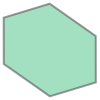

In [3]:
from vgrid.conversion.dggs2geo.isea3h2geo import isea3h2geo

isea3h_geo = isea3h2geo(isea3h_id)
isea3h_geo

### ISEA3H to GeoJSON        

In [2]:
from vgrid.conversion.dggs2geo.isea3h2geo import isea3h2geojson

isea3h_geojson = isea3h2geojson(isea3h_id)
# isea3h_geojson

### Vector to ISEA3H

Processing features: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s]


<Axes: >

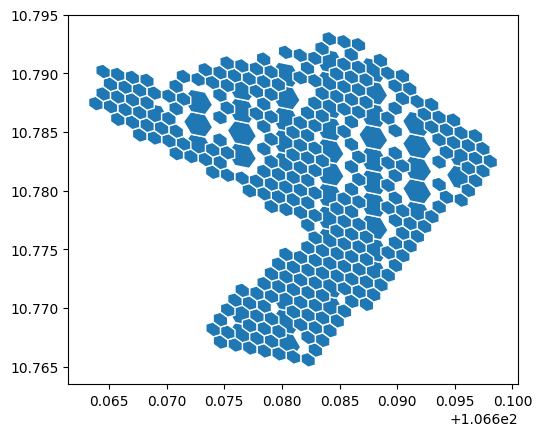

In [5]:
from vgrid.conversion.vector2dggs.vector2isea3h import vector2isea3h

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_isea3h = vector2isea3h(
    file_path,
    resolution=20,
    compact=True,
    topology=True,
    predicate="intersects",
    output_format="gpd",
)
# vector_to_isea3h
vector_to_isea3h.plot(edgecolor="white")

### ISEA3H Compact

<Axes: >

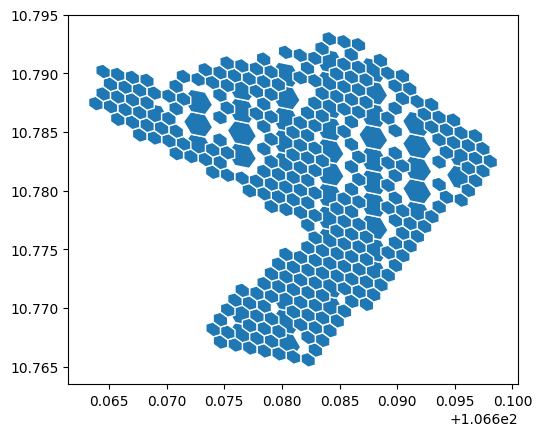

In [6]:
from vgrid.conversion.dggscompact.isea3hcompact import isea3hcompact

isea3h_compacted = isea3hcompact(vector_to_isea3h, output_format="gpd")
isea3h_compacted.plot(edgecolor="white")

### ISEA3H Expand

<Axes: >

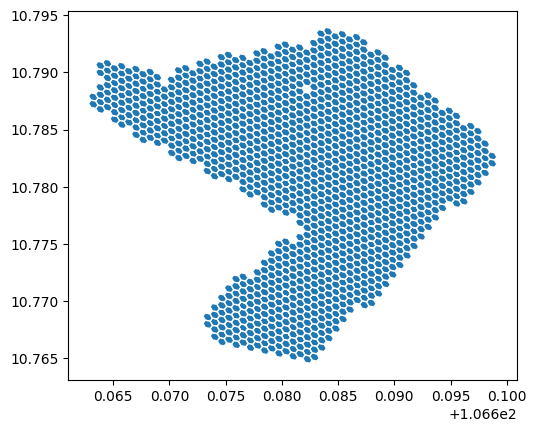

In [7]:
from vgrid.conversion.dggscompact.isea3hcompact import isea3hexpand

isea3h_expanded = isea3hexpand(vector_to_isea3h, resolution=21, output_format="gpd")
isea3h_expanded.plot(edgecolor="white")

### ISEA3H Generator

Generating ISEA3H DGGS: 100%|██████████| 140/140 [00:00<00:00, 1940.79 cells/s]


<Axes: >

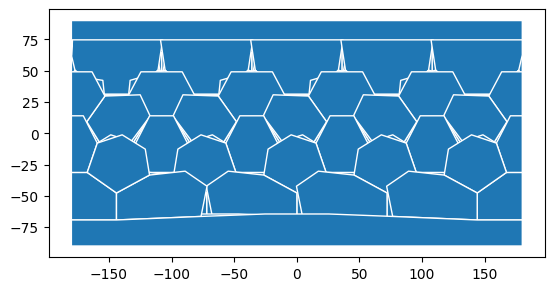

In [8]:
from vgrid.generator.isea3hgrid import isea3hgrid

isea3h_grid = isea3hgrid(resolution=1, output_format="gpd", fix_antimeridian="split")
isea3h_grid.plot(edgecolor="white")

### ISEA3H Inspect

In [ ]:
from vgrid.stats.isea3hstats import isea3hinspect

resolution = 3
isea3h_inspect = isea3hinspect(resolution)
isea3h_inspect.head()

Generating ISEA3H DGGS: 100%|██████████| 2220/2220 [00:00<00:00, 6005.68 cells/s]


,isea3h,resolution,center_lat,center_lon,avg_edge_len,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,"00030,0",3,52.796491,-144.000000,859534.472320,1.927693e+12,5.157207e+06,"POLYGON ((-131.28474 52.37359, -136.05347 59.1...",False,1.017643,0.910791,0.952553,1.0
1,"0003-1,0",3,38.976164,-144.000000,853461.320639,1.893931e+12,5.120768e+06,"POLYGON ((-134.70124 38.65144, -138.77139 45.8...",False,0.999820,0.907620,0.950924,1.0
2,"00030,1",3,57.699020,-121.162465,852569.447432,1.889909e+12,5.115417e+06,"POLYGON ((-108 54.85114, -108 62.05445, -124.6...",False,0.997697,0.907588,0.950912,1.0
3,"00031,0",3,65.610319,-144.000000,854256.212533,1.895550e+12,5.125537e+06,"POLYGON ((-124.68962 64.8145, -131.10399 71.49...",False,1.000674,0.906706,0.950444,1.0
5,"0003-1,1",3,45.137589,-128.011036,855172.453011,1.899693e+12,5.131035e+06,"POLYGON ((-117.92421 43.54752, -119.12139 50.6...",False,1.002862,0.906741,0.950459,1.0


### ISEA3H Normalized Area Histogram

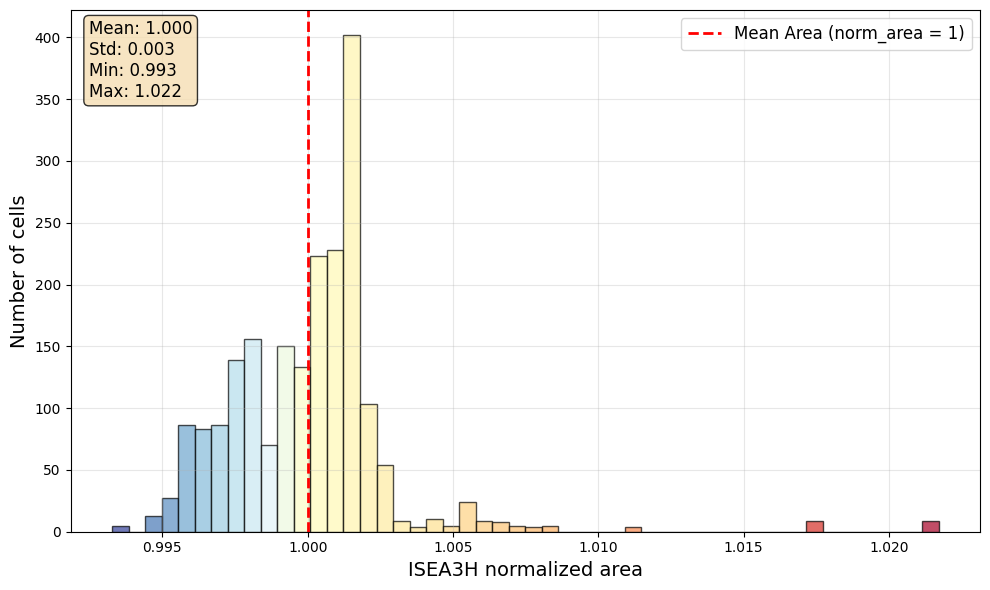

In [10]:
from vgrid.stats.isea3hstats import isea3h_norm_area_hist

isea3h_norm_area_hist(isea3h_inspect)

### Distribution of ISEA3H Area Distortions

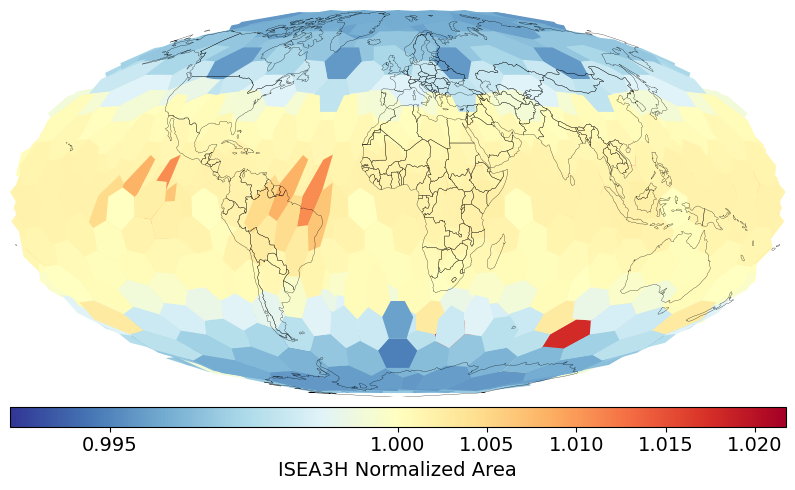

In [11]:
from vgrid.stats.isea3hstats import isea3h_norm_area

isea3h_norm_area(isea3h_inspect)

### ISEA3H IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


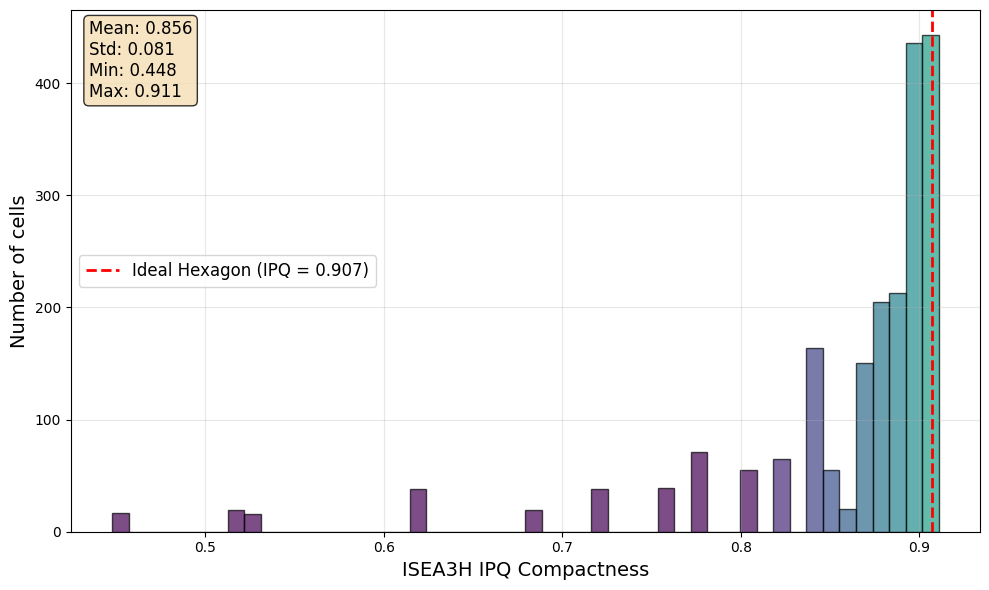

In [12]:
from vgrid.stats.isea3hstats import isea3h_compactness_ipq_hist

isea3h_compactness_ipq_hist(isea3h_inspect)

### Distribution of ISEA3H IPQ Compactness

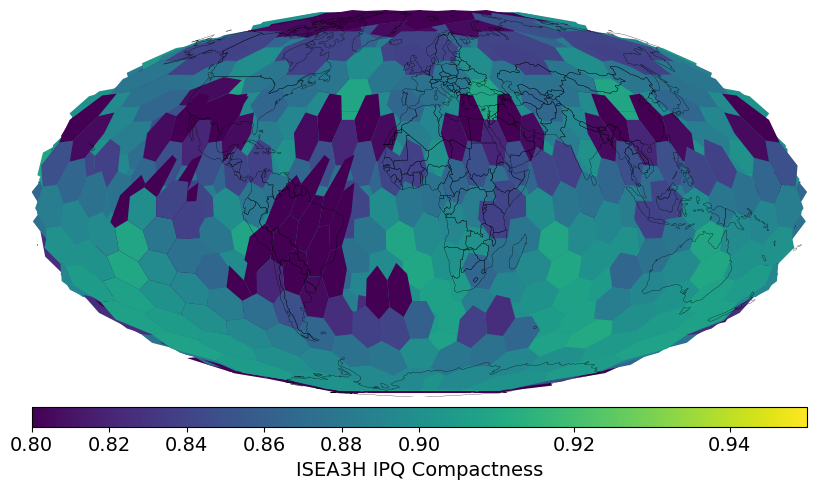

In [13]:
from vgrid.stats.isea3hstats import isea3h_compactness_ipq

isea3h_compactness_ipq(isea3h_inspect)

### ISEA3H Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is [0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

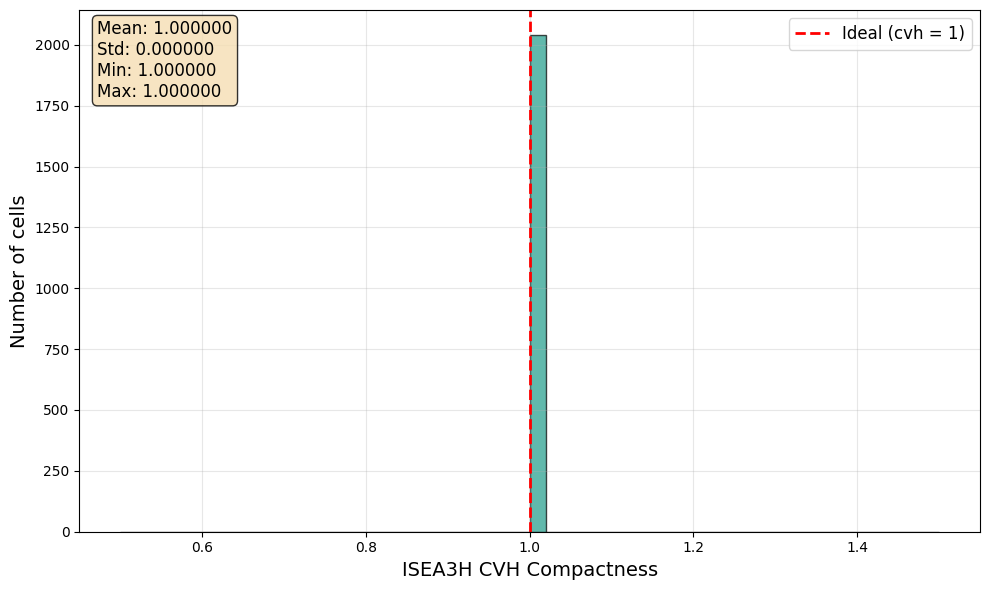

In [14]:
from vgrid.stats.isea3hstats import isea3h_compactness_cvh_hist

isea3h_compactness_cvh_hist(isea3h_inspect)

### Distribution of ISEA3H Convex hull Compactness

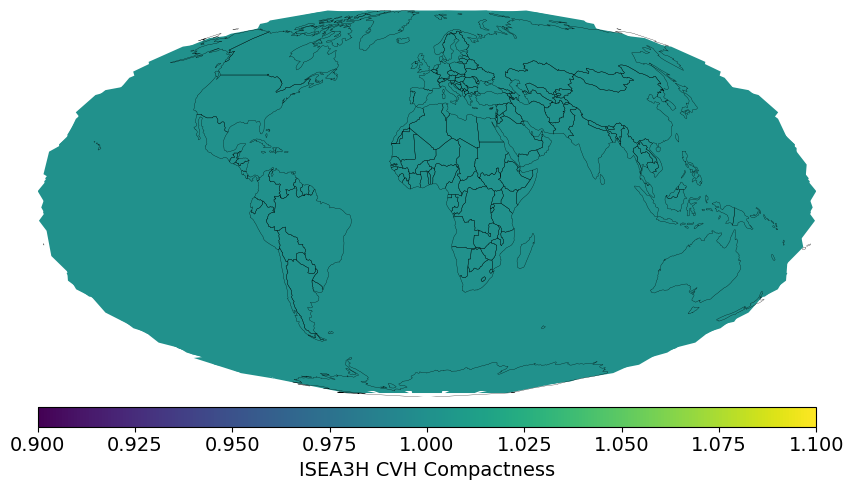

In [15]:
from vgrid.stats.isea3hstats import isea3h_compactness_cvh

isea3h_compactness_cvh(isea3h_inspect)

### ISEA3H Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [16]:
from vgrid.stats.isea3hstats import isea3hstats

isea3hstats("km")

,resolution,number_of_cells,avg_edge_len_km,avg_cell_area_km2,cls_km
0,0,12,9907.682608,4.250547e+07,7462.813606
1,1,32,2476.920652,1.593955e+07,4528.782056
2,2,92,1460.808105,5.544192e+06,2661.730568
3,3,272,849.576775,1.875241e+06,1546.144590
4,4,812,491.710032,6.281596e+05,894.497750
5,5,2432,284.122285,2.097309e+05,516.792340
6,6,7292,164.083063,6.994866e+04,298.438386
7,7,21872,94.742062,2.332048e+04,172.316612
8,8,65612,54.701023,7.773969e+03,99.489569
9,9,196832,31.581971,2.591375e+03,57.440816
